In [26]:
import mitsuba as mi
import drjit as dr
import matplotlib.pyplot as plt
import numpy as np
import torch

mi.set_variant('cuda_ad_rgb', 'metal_ad_rgb', 'llvm_ad_rgb', 'scalar_rgb')
print("Mitsuba variant:", mi.variant())
print("PyTorch CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU: ", torch.cuda.get_device_name(0))

Mitsuba variant: cuda_ad_rgb
PyTorch CUDA: True
GPU:  NVIDIA GeForce RTX 5070


In [45]:
class DataPathTracer(mi.SamplingIntegrator):
    def __init__(self, props):
        super().__init__(props)
        self.max_depth = 20
        self.rr_depth = 100

    def mis_weight(self, pdf_a, pdf_b):
        a2 = pdf_a * pdf_a
        b2 = pdf_b * pdf_b

        w = a2 / (a2 + b2)
        return dr.detach(dr.select(dr.isfinite(w), w, 0.0))

    def collect_paths(self, scene, sampler, ray, active=True):
        ctx = mi.BSDFContext()

        ray = mi.Ray3f(ray)
        beta = mi.Spectrum(1.0)
        eta = mi.Float(1.0)

        prev_si = dr.zeros(mi.Interaction3f)
        prev_bsdf_pdf = mi.Float(1.0)
        prev_bsdf_delta = mi.Bool(True)

        records = []
        L_check = mi.Spectrum(0.0)

        for depth in range(self.max_depth):
            # Trace current ray
            active_before = mi.Bool(active)
            si = scene.ray_intersect(ray, active=active_before)
            valid_hit = active_before & si.is_valid()

            # Evaluate surface or environment emitter
            emitter = si.emitter(scene, active=active_before)
            is_emitter = emitter != None

            # Current path state
            dir_in = -ray.d
            beta_before = mi.Spectrum(beta)

            # Emitter contribution from the current ray
            direct_sample = mi.DirectionSample3f(scene, si, prev_si)
            emitter_pdf = scene.pdf_emitter_direction(
                prev_si,
                direct_sample,
                active=active_before & is_emitter & ~prev_bsdf_delta
            )

            mis_bsdf = self.mis_weight(prev_bsdf_pdf, emitter_pdf)
            Le = emitter.eval(si, active=active_before & is_emitter)
            emitter_hit = Le * mis_bsdf

            # Continue only from a valid surface
            active_next = valid_hit & (depth + 1 < self.max_depth)
            bsdf = si.bsdf()

            # Next-event estimation
            active_emitter = (
                active_next &
                mi.has_flag(bsdf.flags(), mi.BSDFFlags.Smooth)
            )

            ds, emitter_weight = scene.sample_emitter_direction(
                si,
                sampler.next_2d(active_emitter),
                test_visibility=True,
                active=active_emitter
            )

            active_emitter &= ds.pdf > 0
            wo_emitter = si.to_local(ds.d)

            bsdf_value, bsdf_pdf = bsdf.eval_pdf(
                ctx,
                si,
                wo_emitter,
                active_emitter
            )

            mis_emitter = dr.select(
                ds.delta,
                1.0,
                self.mis_weight(ds.pdf, bsdf_pdf)
            )

            nee = dr.select(
                active_emitter,
                bsdf_value * emitter_weight * mis_emitter,
                0.0
            )

            # Contribution generated at this bounce
            bounce_estimator = emitter_hit + nee
            path_contribution = beta_before * bounce_estimator
            L_check += path_contribution

            # Sample the next BSDF direction
            bs, bsdf_weight = bsdf.sample(
                ctx,
                si,
                sampler.next_1d(),
                sampler.next_2d(),
                active_next
            )

            valid_bsdf = active_next & (bs.pdf > 0)
            dir_out = si.to_world(bs.wo)
            next_ray = si.spawn_ray(dir_out)

            # Update transport state
            beta *= bsdf_weight
            eta *= bs.eta

            # Russian roulette
            next_depth = depth + 1
            throughput_max = dr.max(mi.unpolarized_spectrum(beta))

            rr_probability = dr.minimum(
                throughput_max * dr.square(eta),
                0.95
            )

            rr_active = (
                valid_bsdf &
                (throughput_max != 0.0) &
                (next_depth >= self.rr_depth)
            )

            rr_continue = (
                sampler.next_1d(rr_active) < rr_probability
            )

            beta[rr_active] *= dr.rcp(
                dr.detach(rr_probability)
            )

            # Rays that actually continue after Russian roulette
            valid_next = (
                valid_bsdf &
                (throughput_max != 0.0) &
                (~rr_active | rr_continue)
            )

            # Save current bounce
            records.append({
                "depth": depth,

                # Path validity
                "active": mi.Bool(active_before),
                "valid_hit": mi.Bool(valid_hit),
                "is_emitter": mi.Bool(is_emitter),
                "valid_bsdf": mi.Bool(valid_bsdf),
                "valid_next": mi.Bool(valid_next),

                # Geometry
                "position": mi.Point3f(si.p),
                "normal": mi.Normal3f(si.sh_frame.n),

                # Directions
                "dir_in": mi.Vector3f(dir_in),
                "dir_out": mi.Vector3f(dir_out),

                # Transport state
                "beta": mi.Spectrum(beta_before),
                "bsdf_weight": mi.Spectrum(bsdf_weight),
                "bsdf_pdf": mi.Float(bs.pdf),

                # Light estimator
                "emitter_hit": mi.Spectrum(emitter_hit),
                "nee": mi.Spectrum(nee),
                "bounce_estimator": mi.Spectrum(bounce_estimator),
                "path_contribution": mi.Spectrum(path_contribution),

                # Russian roulette
                "rr_active": mi.Bool(rr_active),
                "rr_probability": mi.Float(rr_probability),
            })

            # Save information needed for MIS at the next vertex
            prev_si = mi.Interaction3f(si)
            prev_bsdf_pdf = bs.pdf
            prev_bsdf_delta = mi.has_flag(
                bs.sampled_type,
                mi.BSDFFlags.Delta
            )

            # Move to the next bounce
            ray = next_ray
            active = valid_next

        return records, L_check

    @dr.syntax
    def sample(self, scene, sampler, ray, medium=None, active=True):
        # init 
        ctx = mi.BSDFContext()
        ray = mi.Ray3f(ray)
        L = mi.Spectrum(0.0)
        beta = mi.Spectrum(1.0)

        eta = mi.Float(1.0)
        depth = mi.UInt32(0)

        valid_ray = mi.Bool(False)

        # Information from the previous vertex.
        prev_si = dr.zeros(mi.Interaction3f)
        prev_bsdf_pdf = mi.Float(1.0)
        prev_bsdf_delta = mi.Bool(True)

        # main loop
        while active:
            si = scene.ray_intersect(ray, active=active)
            emitter = si.emitter(scene, active=active)
            is_emitter = emitter != None

            # Probability that NEE could have generated 
            direct_sample = mi.DirectionSample3f(scene, si, prev_si)
            emitter_pdf = scene.pdf_emitter_direction(
                prev_si, 
                direct_sample, 
                active=active & is_emitter & ~prev_bsdf_delta
            )

            mis_bsdf = self.mis_weight(prev_bsdf_pdf, emitter_pdf)

            Le = emitter.eval(si, active=active & is_emitter)

            L += beta * Le * mis_bsdf
            valid_ray |= active & is_emitter

            is_hit = si.is_valid()
            active_next = (active & is_hit & (depth + 1 < self.max_depth))

            bsdf = si.bsdf()
            active_emitter = (active_next & mi.has_flag(bsdf.flags(), mi.BSDFFlags.Smooth))
            ds, emitter_weight = scene.sample_emitter_direction(
                si, 
                sampler.next_2d(active_emitter),
                test_visibility=True,
                active=active_emitter
            )

            active_emitter &= ds.pdf > 0
            wo_emitter = si.to_local(ds.d)

            bsdf_value, bsdf_pdf = bsdf.eval_pdf(
                ctx, 
                si,
                wo_emitter,
                active_emitter
            )

            mis_emitter = dr.select(ds.delta, 1.0, self.mis_weight(ds.pdf, bsdf_pdf))

            direct_contribution = (beta * bsdf_value * emitter_weight * mis_emitter)
            L += dr.select(active_emitter, direct_contribution, 0.0)

            bs, bsdf_weight = bsdf.sample(ctx, si, sampler.next_1d(), sampler.next_2d(), active_next)
            active_bsdf = active_next & (bs.pdf > 0)

            new_direction = si.to_world(bs.wo)
            ray = si.spawn_ray(new_direction)

            beta *= bsdf_weight
            eta *= bs.eta

            non_null = (active_bsdf & ~mi.has_flag(bs.sampled_type, mi.BSDFFlags.Null))
            valid_ray |= non_null

            prev_si = mi.Interaction3f(si)
            prev_bsdf_pdf = bs.pdf
            prev_bsdf_delta = mi.has_flag(bs.sampled_type, mi.BSDFFlags.Delta)

            depth += 1

            throughput_max = dr.max(mi.unpolarized_spectrum(beta))

            rr_probability = dr.minimum(
                throughput_max * dr.square(eta),
                0.95
            )

            rr_active = (
                active_bsdf &
                (throughput_max != 0.0) &
                (depth >= self.rr_depth)
            )

            rr_continue = (
                sampler.next_1d(rr_active) < rr_probability
            )

            beta[rr_active] *= dr.rcp(
                dr.detach(rr_probability)
            )

            active = (
                active_bsdf &
                (throughput_max != 0.0) &
                (~rr_active | rr_continue)
            )

        return dr.select(valid_ray, L, 0.0), valid_ray, []

In [46]:
SCENE_PATH = "assets/cornell-box/scene.xml"

scene = mi.load_file(SCENE_PATH)
sensor = scene.sensors()[0]

NUM_SAMPLES = 4096
SEED = 42

print("Scene       :", SCENE_PATH)
print("Num samples :", NUM_SAMPLES)
print("Seed        :", SEED)

Scene       : assets/cornell-box/scene.xml
Num samples : 4096
Seed        : 42


In [47]:
# --------------------------------------------------
# Cell: Validate collect_paths()
# --------------------------------------------------

camera_sampler = mi.load_dict({"type": "independent"})
camera_sampler.seed(SEED, NUM_SAMPLES)

ray, _ = sensor.sample_ray(
    time=mi.Float(0.0),
    sample1=camera_sampler.next_1d(),
    sample2=camera_sampler.next_2d(),
    sample3=camera_sampler.next_2d()
)

# All 4096 rays start active
active_mask = dr.full(mi.Bool, True, NUM_SAMPLES)

# Same random stream
sampler_collect = mi.load_dict({"type": "independent"})
sampler_sample = mi.load_dict({"type": "independent"})

sampler_collect.seed(SEED + 1, NUM_SAMPLES)
sampler_sample.seed(SEED + 1, NUM_SAMPLES)

tracer = DataPathTracer(mi.Properties())

# Collect path data
records, L_check = tracer.collect_paths(
    scene,
    sampler_collect,
    ray,
    active=active_mask
)

# Run original estimator
L_sample, valid_sample, _ = tracer.sample(
    scene,
    sampler_sample,
    ray,
    active=active_mask
)

# Match sample() output mask
L_check_masked = dr.select(valid_sample, L_check, 0.0)

# Compare
error = dr.abs(L_sample - L_check_masked)

print("Estimator validation")
print("--------------------")
print("Mean L_sample :", dr.mean(mi.luminance(L_sample)))
print("Mean L_check  :", dr.mean(mi.luminance(L_check_masked)))
print("Mean error    :", dr.mean(mi.luminance(error)))
print("Max error     :", dr.max(mi.luminance(error)))

print("\nPath statistics")
print("--------------------")

for record in records:
    depth = record["depth"]
    hits = int(dr.count(record["valid_hit"])[0])
    bsdf = int(dr.count(record["valid_bsdf"])[0])
    next_paths = int(dr.count(record["valid_next"])[0])

    print(
        f"Depth {depth:2d} | "
        f"hit {hits:4d} | "
        f"bsdf {bsdf:4d} | "
        f"next {next_paths:4d}"
    )

Estimator validation
--------------------
Mean L_sample : [0.153961]
Mean L_check  : [0.153961]
Mean error    : [1.27318e-09]
Max error     : [5.63784e-08]

Path statistics
--------------------
Depth  0 | hit 4096 | bsdf 4096 | next 4071
Depth  1 | hit 3055 | bsdf 3055 | next 3032
Depth  2 | hit 2594 | bsdf 2594 | next 2570
Depth  3 | hit 2183 | bsdf 2183 | next 2157
Depth  4 | hit 1889 | bsdf 1889 | next 1873
Depth  5 | hit 1637 | bsdf 1637 | next 1620
Depth  6 | hit 1440 | bsdf 1440 | next 1428
Depth  7 | hit 1233 | bsdf 1233 | next 1222
Depth  8 | hit 1084 | bsdf 1084 | next 1078
Depth  9 | hit  955 | bsdf  955 | next  947
Depth 10 | hit  853 | bsdf  853 | next  847
Depth 11 | hit  758 | bsdf  758 | next  752
Depth 12 | hit  675 | bsdf  675 | next  669
Depth 13 | hit  593 | bsdf  593 | next  587
Depth 14 | hit  521 | bsdf  521 | next  519
Depth 15 | hit  462 | bsdf  462 | next  459
Depth 16 | hit  416 | bsdf  416 | next  414
Depth 17 | hit  371 | bsdf  371 | next  371
Depth 18 | hit

Path length statistics
----------------------
Number of paths : 4096
Mean length     : 6.208251953125
Min length      : 1
Max length      : 20

Length distribution
----------------------
Length  1 : 1041 (25.42%)
Length  2 :  461 (11.25%)
Length  3 :  411 (10.03%)
Length  4 :  294 ( 7.18%)
Length  5 :  252 ( 6.15%)
Length  6 :  197 ( 4.81%)
Length  7 :  207 ( 5.05%)
Length  8 :  149 ( 3.64%)
Length  9 :  129 ( 3.15%)
Length 10 :  102 ( 2.49%)
Length 11 :   95 ( 2.32%)
Length 12 :   83 ( 2.03%)
Length 13 :   82 ( 2.00%)
Length 14 :   72 ( 1.76%)
Length 15 :   59 ( 1.44%)
Length 16 :   46 ( 1.12%)
Length 17 :   45 ( 1.10%)
Length 18 :   42 ( 1.03%)
Length 19 :   44 ( 1.07%)
Length 20 :  285 ( 6.96%)


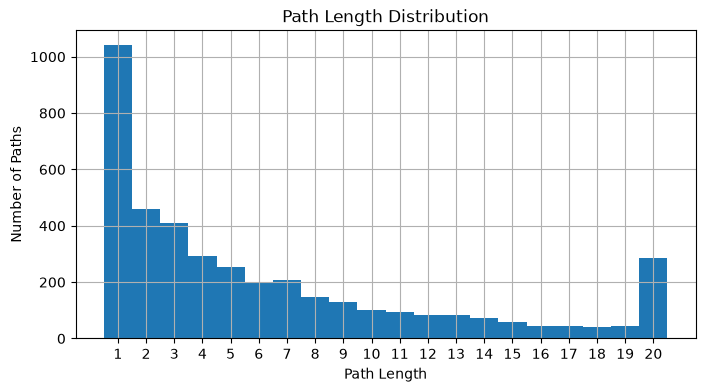

In [48]:
# --------------------------------------------------
# Cell: Analyze path length distribution
# --------------------------------------------------

valid_per_depth = []

for record in records:
    mask = np.array(record["valid_hit"], copy=False)
    valid_per_depth.append(mask.astype(np.int32))

valid_per_depth = np.stack(valid_per_depth, axis=1)

# [NUM_SAMPLES, MAX_DEPTH]
path_lengths = valid_per_depth.sum(axis=1)

print("Path length statistics")
print("----------------------")
print("Number of paths :", len(path_lengths))
print("Mean length     :", path_lengths.mean())
print("Min length      :", path_lengths.min())
print("Max length      :", path_lengths.max())

print("\nLength distribution")
print("----------------------")

for length in range(1, tracer.max_depth + 1):
    count = np.sum(path_lengths == length)

    print(
        f"Length {length:2d} : "
        f"{count:4d} "
        f"({100.0 * count / NUM_SAMPLES:5.2f}%)"
    )

plt.figure(figsize=(8, 4))
plt.hist(
    path_lengths,
    bins=np.arange(0.5, tracer.max_depth + 1.5, 1)
)

plt.xlabel("Path Length")
plt.ylabel("Number of Paths")
plt.title("Path Length Distribution")
plt.xticks(range(1, tracer.max_depth + 1))
plt.grid(True)
plt.show()

In [49]:
# --------------------------------------------------
# Cell: Build continuation-radiance targets
# --------------------------------------------------

continuation_targets = [None] * len(records)

# Start from zero after the final recorded bounce
R_next = mi.Spectrum(0.0)

for depth in reversed(range(len(records))):
    record = records[depth]

    valid_hit = record["valid_hit"]
    valid_next = record["valid_next"]

    C = record["bounce_estimator"]
    W = record["bsdf_weight"]

    # Remaining radiance from the current bounce
    R = C + dr.select(
        valid_next,
        W * R_next,
        0.0
    )

    R = dr.select(
        valid_hit,
        R,
        0.0
    )

    continuation_targets[depth] = mi.Spectrum(R)
    R_next = R

print("Continuation targets created.")
print()

for depth in range(len(records)):
    valid = records[depth]["valid_hit"]

    mean_R = dr.mean(
        mi.luminance(
            dr.select(valid, continuation_targets[depth], 0.0)
        )
    )

    print(
        f"Depth {depth:2d} | "
        f"Mean continuation radiance = {mean_R}"
    )

Continuation targets created.

Depth  0 | Mean continuation radiance = [0.153961]
Depth  1 | Mean continuation radiance = [0.0579684]
Depth  2 | Mean continuation radiance = [0.0531693]
Depth  3 | Mean continuation radiance = [0.0432836]
Depth  4 | Mean continuation radiance = [0.037973]
Depth  5 | Mean continuation radiance = [0.0329449]
Depth  6 | Mean continuation radiance = [0.0285517]
Depth  7 | Mean continuation radiance = [0.024667]
Depth  8 | Mean continuation radiance = [0.0214508]
Depth  9 | Mean continuation radiance = [0.0192753]
Depth 10 | Mean continuation radiance = [0.0173732]
Depth 11 | Mean continuation radiance = [0.0159564]
Depth 12 | Mean continuation radiance = [0.0129281]
Depth 13 | Mean continuation radiance = [0.0105417]
Depth 14 | Mean continuation radiance = [0.00910577]
Depth 15 | Mean continuation radiance = [0.00832329]
Depth 16 | Mean continuation radiance = [0.00710395]
Depth 17 | Mean continuation radiance = [0.00579223]
Depth 18 | Mean continuation rad

In [50]:
# --------------------------------------------------
# Cell: Analyze continuation targets
# --------------------------------------------------

print("Continuation target statistics")
print("------------------------------")

for depth in range(len(records)):
    valid = records[depth]["valid_hit"]
    R = continuation_targets[depth]

    num_valid = int(dr.count(valid)[0])

    if num_valid == 0:
        continue

    luminance_R = mi.luminance(R)

    # Sum only valid paths, then divide by valid path count
    valid_sum = dr.sum(
        dr.select(valid, luminance_R, 0.0)
    )

    conditional_mean = valid_sum / num_valid

    print(
        f"Depth {depth:2d} | "
        f"valid {num_valid:4d} | "
        f"mean R = {conditional_mean}"
    )

Continuation target statistics
------------------------------
Depth  0 | valid 4096 | mean R = [0.153961]
Depth  1 | valid 3055 | mean R = [0.0777213]
Depth  2 | valid 2594 | mean R = [0.0839558]
Depth  3 | valid 2183 | mean R = [0.0812138]
Depth  4 | valid 1889 | mean R = [0.0823384]
Depth  5 | valid 1637 | mean R = [0.0824327]
Depth  6 | valid 1440 | mean R = [0.0812139]
Depth  7 | valid 1233 | mean R = [0.0819432]
Depth  8 | valid 1084 | mean R = [0.081054]
Depth  9 | valid  955 | mean R = [0.0826718]
Depth 10 | valid  853 | mean R = [0.0834241]
Depth 11 | valid  758 | mean R = [0.0862237]
Depth 12 | valid  675 | mean R = [0.0784497]
Depth 13 | valid  593 | mean R = [0.072814]
Depth 14 | valid  521 | mean R = [0.0715878]
Depth 15 | valid  462 | mean R = [0.0737926]
Depth 16 | valid  416 | mean R = [0.0699465]
Depth 17 | valid  371 | mean R = [0.0639488]
Depth 18 | valid  329 | mean R = [0.0440461]
Depth 19 | valid  285 | mean R = [1.9426e-05]


In [51]:
# --------------------------------------------------
# Cell: Analyze continuation target distribution
# --------------------------------------------------

print("Continuation target distribution")
print("--------------------------------")

for depth in range(len(records)):
    valid = np.array(records[depth]["valid_hit"], copy=False).astype(bool)

    R = continuation_targets[depth]
    lum = np.array(mi.luminance(R), copy=False)

    values = lum[valid]

    if len(values) == 0:
        continue

    print(
        f"Depth {depth:2d} | "
        f"N {len(values):4d} | "
        f"mean {values.mean():8.4f} | "
        f"median {np.median(values):8.4f} | "
        f"p90 {np.percentile(values, 90):8.4f} | "
        f"p99 {np.percentile(values, 99):8.4f} | "
        f"max {values.max():8.4f}"
    )

Continuation target distribution
--------------------------------
Depth  0 | N 4096 | mean   0.1540 | median   0.0598 | p90   0.1793 | p99   0.5195 | max  12.4860
Depth  1 | N 3055 | mean   0.0777 | median   0.0530 | p90   0.1616 | p99   0.5303 | max   0.9802
Depth  2 | N 2594 | mean   0.0840 | median   0.0593 | p90   0.1732 | p99   0.4978 | max   1.1633
Depth  3 | N 2183 | mean   0.0812 | median   0.0583 | p90   0.1649 | p99   0.5222 | max   0.8301
Depth  4 | N 1889 | mean   0.0823 | median   0.0570 | p90   0.1718 | p99   0.5223 | max   0.8856
Depth  5 | N 1637 | mean   0.0824 | median   0.0571 | p90   0.1755 | p99   0.5891 | max   0.9324
Depth  6 | N 1440 | mean   0.0812 | median   0.0561 | p90   0.1721 | p99   0.4549 | max   0.9447
Depth  7 | N 1233 | mean   0.0819 | median   0.0589 | p90   0.1676 | p99   0.5195 | max   0.8699
Depth  8 | N 1084 | mean   0.0811 | median   0.0603 | p90   0.1681 | p99   0.4348 | max   0.8078
Depth  9 | N  955 | mean   0.0827 | median   0.0597 | p90   0

In [52]:
# --------------------------------------------------
# Cell: Analyze continuation target distribution
# --------------------------------------------------

print("Continuation target distribution")
print("--------------------------------")

for depth in range(len(records)):
    valid = np.array(
        records[depth]["valid_hit"],
        copy=False
    ).astype(bool)

    R = continuation_targets[depth]
    lum = np.array(
        mi.luminance(R),
        copy=False
    )

    values = lum[valid]

    if len(values) == 0:
        continue

    print(
        f"Depth {depth:2d} | "
        f"N {len(values):4d} | "
        f"mean {values.mean():8.4f} | "
        f"median {np.median(values):8.4f} | "
        f"p90 {np.percentile(values, 90):8.4f} | "
        f"p99 {np.percentile(values, 99):8.4f} | "
        f"max {values.max():8.4f}"
    )

Continuation target distribution
--------------------------------
Depth  0 | N 4096 | mean   0.1540 | median   0.0598 | p90   0.1793 | p99   0.5195 | max  12.4860
Depth  1 | N 3055 | mean   0.0777 | median   0.0530 | p90   0.1616 | p99   0.5303 | max   0.9802
Depth  2 | N 2594 | mean   0.0840 | median   0.0593 | p90   0.1732 | p99   0.4978 | max   1.1633
Depth  3 | N 2183 | mean   0.0812 | median   0.0583 | p90   0.1649 | p99   0.5222 | max   0.8301
Depth  4 | N 1889 | mean   0.0823 | median   0.0570 | p90   0.1718 | p99   0.5223 | max   0.8856
Depth  5 | N 1637 | mean   0.0824 | median   0.0571 | p90   0.1755 | p99   0.5891 | max   0.9324
Depth  6 | N 1440 | mean   0.0812 | median   0.0561 | p90   0.1721 | p99   0.4549 | max   0.9447
Depth  7 | N 1233 | mean   0.0819 | median   0.0589 | p90   0.1676 | p99   0.5195 | max   0.8699
Depth  8 | N 1084 | mean   0.0811 | median   0.0603 | p90   0.1681 | p99   0.4348 | max   0.8078
Depth  9 | N  955 | mean   0.0827 | median   0.0597 | p90   0